In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
import sys
import json
import wandb
import torch.nn as nn
from torch.utils.data import DataLoader

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


# load the model weights

In [35]:
from b_models.configs.ddpm_config import DDPM_Simple_Disk_Training_Config
from utils.wandb_utils import get_wandb_run_name, get_artifact

project_name = "ddpm_simple_disk"
model_num = 4  # 2 for noise

# construct config from wandb run
model_path, artifact, config, run_config = get_artifact(model_num=model_num, project_name=project_name)
config = DDPM_Simple_Disk_Training_Config.from_dict(run_config)

/mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/ddpm_simple_disk
wandb run name: aguvb2cu


wandb:   1 of 1 files downloaded.  


In [36]:
config.parameterization

'velocity2'

In [37]:
from b_models.ddpm.ddpm_lightning import DDPM_Lightning
from b_models.ddpm.ddpm_inference import DDPM_Inference

lightning_model = DDPM_Lightning.load_from_checkpoint(checkpoint_path=model_path, config=config)
ddpm_inference = DDPM_Inference(ddpm=lightning_model.model, config=config).to(device)

# load the dataset

In [38]:
from a_datasets.sos.data import load_sos_data
from a_datasets.disks.data import load_simple_disk_dataset

cpu_tensor, _ = load_simple_disk_dataset(
    num_samples=config.dataset_size,
    img_size=config.image_dim, 
    foreground=config.foreground,
    background=config.background,
    outer_radius=config.outer_radius, 
    transition_width=config.transition_width,
    seed=config.dataset_seed,
    cx_range=config.cx_range,
    cy_range=config.cy_range,
)
print(cpu_tensor.shape)
print(cpu_tensor.min(), cpu_tensor.max())
print(config.dataset_size)


torch.Size([100000, 1, 28, 28])
tensor(0.) tensor(1.)
100000


In [39]:
from torchvision import transforms

from a_datasets.custom_dataset_classes import CustomTensorDataset

transform = transforms.Compose(
    [
        transforms.Normalize((0.5,), (0.5,)),
    ]
)
train_dataset = CustomTensorDataset(cpu_tensor, transform)

input_img = train_dataset[31]
print(input_img.shape)
print(input_img.min())
print(input_img.max())


torch.Size([1, 28, 28])
tensor(-1.)
tensor(1.)


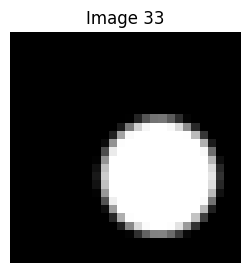

-1.0 1.0
---
-1.0 1.0


In [40]:
from utils.base_utils import t2n, to_01

"""select an image from cis dataset"""
img_idx = 33
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(target_img, cmap='gray', vmin=-1, vmax=1)
ax.axis('off')
ax.set_title(f"Image {img_idx}")
plt.show()

print(train_dataset[img_idx].min().item(), train_dataset[img_idx].max().item())
print('---')
print(target_img.min(), target_img.max())

# unconditional generation

In [41]:
"""generate images from ddpm_inference"""
ddpm_inference.unconditional_sample(N=4)
gen_img = ddpm_inference.x_t
print(gen_img.shape)
print(gen_img.min(), gen_img.max())

torch.Size([4, 1, 28, 28])
tensor(-1.0793, device='cuda:0') tensor(1.0706, device='cuda:0')


(4, 28, 28, 1)
-0.03962773 1.0353034


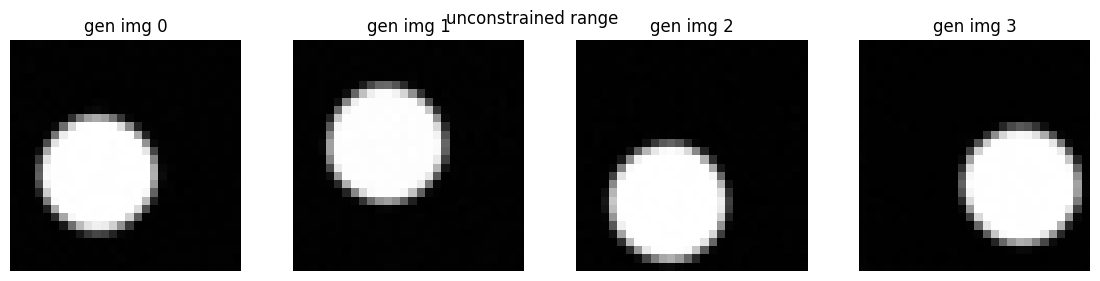

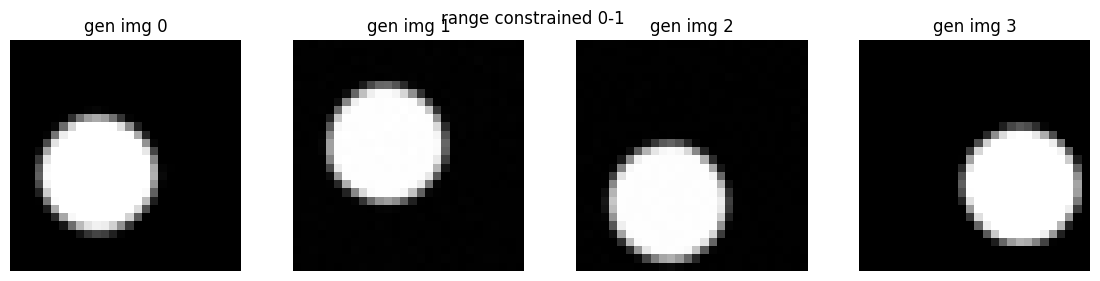

In [42]:
# figure
gen_img_np = t2n(gen_img)
gen_img_np = np.transpose(gen_img_np, (0,2,3,1))
gen_img_np = to_01(gen_img_np)
print(gen_img_np.shape)
print(gen_img_np.min(), gen_img_np.max())


fig, ax = plt.subplots(1,4, figsize=(14,3))
for i in range(0,4):
    # ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('unconstrained range')
plt.show()

fig, ax = plt.subplots(1,4, figsize=(14,3))
for i in range(0, 4):
    ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    # ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('range constrained 0-1')
# fig.tight_layout()
plt.show()
# ax[1].axis('off')
# ax[1].set_title('Generated Image')